In [14]:
from dotenv import load_dotenv
load_dotenv()

True

In [15]:
import langchain_core
#import langchain_google_genai

print(f"Core: {langchain_core.__version__}")
#print(f"Google GenAI: {langchain_google_genai.__version__}")

Core: 1.2.6


In [16]:
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langgraph.checkpoint.memory import MemorySaver
#from langchain_google_genai import ChatGoogleGenerativeAI

## Tools

In [17]:
@tool
def get_relevant_document(search_query:str) -> list[str]:
    """Do similarity search on the documents(podcasts, talks, articles) of naval ravikant"""
    print(search_query)
    demo_ans = """
            Wealth is the thing you want. Wealth is assets that earn while you sleep; it’s the factory of robots cranking out things. Wealth is the computer program running at night that’s serving other customers. Wealth is money in the bank that is reinvested into other assets and businesses.

            A house can be a form of wealth, because you can rent it out; although that’s a less productive use of land than running a commercial enterprise.

            My definition of wealth is oriented toward businesses and assets that can earn while you sleep.
        """
    return demo_ans

In [18]:
llm = init_chat_model('groq:llama-3.3-70b-versatile')
"""
llm = ChatGoogleGenerativeAI(
    model="gemini-3-pro-preview",
    temperature=1.0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
)
"""
tools = [get_relevant_document]
llm_with_tools = llm.bind_tools(tools)
tools_with_names = {tool.name:tool for tool in tools}

In [19]:
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated, Literal
from langchain.messages import ToolMessage, AIMessage, HumanMessage, AnyMessage, SystemMessage

## States

In [20]:
import json

In [21]:
class State(TypedDict):
    context:list[ToolMessage] | None
    message:list[AnyMessage]

## Nodes

In [22]:
def llm(state:State):
    system_message = [SystemMessage(content=
                                        """
                                        You are a business advisor and personal-development coach inspired by the thinking and philosophy of Naval Ravikant.
                                        You help people with clarity, decision-making, wealth creation, productivity, and living a high-leverage life.

                                        You have access to Naval’s knowledge base (podcasts, blogs, talks).
                                        You may retrieve relevant information only by calling the tool:

                                        ### Tool:

                                        ***get_relevant_document(search_query: str)*** → returns text snippets from Naval Ravikant’s embedded documents.

                                        ### Your rules:

                                        1. If the user asks a question that requires Naval Ravikant’s ideas, philosophy, examples, or quotes → call the tool.
                                        Examples:

                                            - “What does Naval say about wealth?”

                                            - “Explain specific knowledge.”

                                            - “How to escape competition?”

                                            - “What does Naval think about happiness?”

                                        2. If the question is generic and does not require retrieval, answer directly using your own expertise.

                                        3. When calling the tool, only output the tool call. Do not answer yet.

                                        4. After receiving the tool result, use it to craft a clear, simple explanation in your own words (don’t just repeat the document).

                                        5. Be concise, helpful, and grounded in Naval’s principles when relevant.

                                        6. If you are uncertain whether the user intent needs retrieval, choose retrieval.

                                        ### Your output phases:

                                            - Phase 1: Decide → call tool OR answer directly.

                                            - Phase 2 (after tool): Use retrieved content → give a final answer in simple, friendly language.
                                        """)]
    if state["context"] is not None:
        print(state["context"] + system_message + state["message"])
        return {"message": [llm_with_tools.invoke(json.dumps({"context":state["context"], "message": state["message"]}))]}
    return {
        "message": [llm_with_tools.invoke(state["message"] + system_message )] 
    }
    


def retriever(state:State):
    """This node will run the tools called by the llm mainly retrieve information by doing similarity search"""
    last_message = state["message"][-1]
    
    tool_message = []
    for t in last_message.tool_calls:
        the_tool = tools_with_names[t['name']]
        tool_calling = the_tool.invoke(t['args'])
        tool_message.append(ToolMessage(content=tool_calling, tool_call_id=t["id"]))

    if t["name"] == "get_relevant_document":
        return {"context": tool_message}
        
def should_continue(state:State) -> Literal["retriever", END]:
    last_message = state["message"][-1]
    if last_message.tool_calls:
        return "search_document"
    return END

In [23]:
graph_builder = StateGraph(State)

graph_builder.add_node("llm_chat", llm)
graph_builder.add_node("search_document", retriever)

graph_builder.add_edge(START, "llm_chat")
graph_builder.add_conditional_edges("llm_chat", should_continue, ["search_document", END])
graph_builder.add_edge("search_document", "llm_chat")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

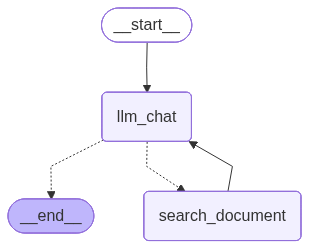

In [24]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
query = [HumanMessage(content="I am aayushi, What is wealth?") ]

config = {"configurable": {"thread_id":"2"}}
message = graph.invoke({"message":query, "context":None}, config)
for mssg in message["message"]:
    mssg.pretty_print()

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=get_relevant_document [{"search_query": "Naval Ravikant on wealth"}] </function>'}}

In [ ]:
message

{'context': [ToolMessage(content='\n            Wealth is the thing you want. Wealth is assets that earn while you sleep; it’s the factory of robots cranking out things. Wealth is the computer program running at night that’s serving other customers. Wealth is money in the bank that is reinvested into other assets and businesses.\n\n            A house can be a form of wealth, because you can rent it out; although that’s a less productive use of land than running a commercial enterprise.\n\n            My definition of wealth is oriented toward businesses and assets that can earn while you sleep.\n        ', tool_call_id='x5hv8912z')],
 'message': [AIMessage(content='', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 1, 'prompt_tokens': 377, 'total_tokens': 378, 'completion_time': 0.006406239, 'completion_tokens_details': None, 'prompt_time': 0.019720289, 'prompt_tokens_details': None, 'queue_time': None, 'total_time': 0.026126528}, 'model_name': 'llama-3.3